# WEA Notebook — Spectral and Network Analysis of the S\&P 500

This notebook is designed for a **conference paper (WEA 2026)** centered on the dynamic structure of the S\&P 500 through:

- rolling correlation matrices
- spectral analysis
- market mode and eigenportfolios
- sector aggregation
- network filtering with **MST**
- community structure and sector alignment

The notebook uses:

- `SnP_daily_update.csv`
- `constituents.csv`
- `sector-counts.csv`

The core strategy is:

- use the **full correlation matrix** for spectral analysis
- use the **minimum spanning tree (MST)** for network interpretation and visualization

## Suggested paper narrative

A concise conference framing is:

> We study the collective organization of the S\&P 500 using rolling correlation matrices, spectral descriptors, eigenportfolios, and filtered dependence networks. The spectral block captures market synchronization and regime changes, while the MST and community structure reveal interpretable sector organization.

Possible sections:

1. Data and preprocessing
2. Rolling dependence matrices
3. Spectral descriptors and market mode
4. Eigenportfolios and sector contributions
5. MST structure and centrality
6. Community detection and sector alignment
7. Regime comparison: pre-COVID, COVID, post-COVID

In [1]:
# =============================
# 0. Imports
# =============================
import warnings
warnings.filterwarnings('ignore')

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from collections import Counter
from itertools import permutations

from scipy.linalg import eigh
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
# =============================
# 1. File paths
# =============================
DATA_PATH = 'SnP_daily_update.csv'
CONSTITUENTS_PATH = 'constituents.csv'
SECTOR_COUNTS_PATH = 'sector-counts.csv'

for p in [DATA_PATH, CONSTITUENTS_PATH, SECTOR_COUNTS_PATH]:
    print(p, '->', os.path.exists(p))

SnP_daily_update.csv -> True
constituents.csv -> True
sector-counts.csv -> True


## 1. Parsing the raw S\&P file

The Kaggle file is not in tidy format. It stores variable types in the first row and tickers in the second row. We extract only the `Close` fields and build a standard price matrix.

In [3]:
# =============================
# 2. Load raw CSV and parse Close prices
# =============================
raw = pd.read_csv(DATA_PATH, header=None)
raw.shape

(4086, 2516)

In [4]:
def parse_close_matrix(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract a date-indexed close-price matrix from the Kaggle S&P raw CSV.
    Row 0: field names such as Close/Open/High/Low/Volume
    Row 1: ticker symbols
    Row 2: date label row
    Row 3 onward: observations
    """
    header_field = raw_df.iloc[0]
    header_ticker = raw_df.iloc[1]

    date_col = raw_df.iloc[3:, 0].copy()
    dates = pd.to_datetime(date_col, errors='coerce')

    close_cols = [j for j in range(raw_df.shape[1])
                  if str(header_field.iloc[j]).strip() == 'Close']
    tickers = [str(header_ticker.iloc[j]).strip() for j in close_cols]

    close_data = raw_df.iloc[3:, close_cols].copy()
    close_data.columns = tickers
    close_data = close_data.apply(pd.to_numeric, errors='coerce')
    close_data.index = dates
    close_data = close_data[~close_data.index.isna()]
    close_data = close_data.sort_index()
    close_data = close_data[~close_data.index.duplicated(keep='first')]
    close_data.index.name = 'Date'
    return close_data

prices = parse_close_matrix(raw)
print('Prices shape:', prices.shape)
prices.head()

Prices shape: (4083, 503)


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,19.856194,6.412382,NaN,NaN,18.321970,7.601905,31.492184,37.090000,21.829472,20.289297,...,9.320827,40.699493,12.087927,37.630966,NaN,NaN,18.434782,51.725548,28.670000,NaN
2010-01-05,19.640499,6.423469,NaN,NaN,18.173939,7.576549,31.686802,37.700001,21.795012,20.398899,...,9.518696,43.174786,11.944564,37.777912,NaN,NaN,18.371735,53.362965,28.620001,NaN
2010-01-06,19.570707,6.321296,NaN,NaN,18.274878,7.543795,32.023670,37.619999,21.753654,20.347326,...,9.413444,42.608475,11.967507,38.104420,NaN,NaN,18.240404,53.345745,28.400000,NaN
2010-01-07,19.545340,6.309611,NaN,NaN,18.426266,7.499420,31.993711,36.889999,21.581337,20.134567,...,9.371347,43.518417,11.915895,37.984695,NaN,NaN,18.235142,54.569496,27.690001,NaN
2010-01-08,19.538994,6.351557,NaN,NaN,18.520464,7.484628,31.866453,36.689999,21.705404,19.883127,...,9.285042,43.206619,11.921631,37.832325,NaN,NaN,18.240404,53.423302,27.600000,NaN


In [6]:
# Quick inspection of missingness and time span
print('Date range:', prices.index.min().date(), 'to', prices.index.max().date())
coverage = prices.notna().mean().sort_values()
print('Coverage summary:')
print(coverage.describe())

Date range: 2010-01-04 to 2026-03-27
Coverage summary:
count    503.000000
mean       0.941451
std        0.170913
min        0.025716
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
dtype: float64


## 2. Constituents and sector metadata

This file lets us map each ticker to:

- security name
- GICS sector
- GICS sub-industry

This is essential for sector-level interpretation of eigenportfolios and clusters.

In [7]:
# =============================
# 3. Load constituent metadata
# =============================
constituents = pd.read_csv(CONSTITUENTS_PATH)
constituents.columns = [c.strip() for c in constituents.columns]
constituents['Symbol'] = constituents['Symbol'].astype(str).str.strip()
constituents.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [8]:
# Keep only tickers present in both datasets
common_tickers = sorted(set(prices.columns).intersection(set(constituents['Symbol'])))
print('Tickers in price matrix:', prices.shape[1])
print('Tickers in constituents:', constituents.shape[0])
print('Common tickers:', len(common_tickers))

prices = prices[common_tickers].copy()
meta = constituents[constituents['Symbol'].isin(common_tickers)].copy()
meta = meta.drop_duplicates(subset='Symbol').set_index('Symbol')

print('Filtered price shape:', prices.shape)
print('Metadata shape:', meta.shape)

Tickers in price matrix: 503
Tickers in constituents: 503
Common tickers: 501
Filtered price shape: (4083, 501)
Metadata shape: (501, 7)


In [9]:
# Sector distribution of the retained universe
sector_counts = meta['GICS Sector'].value_counts().sort_values(ascending=False)
sector_counts

,count
GICS Sector,
Industrials,79
Financials,75
Information Technology,73
Health Care,59
Consumer Discretionary,48
Consumer Staples,34
Utilities,31
Real Estate,31
Materials,26


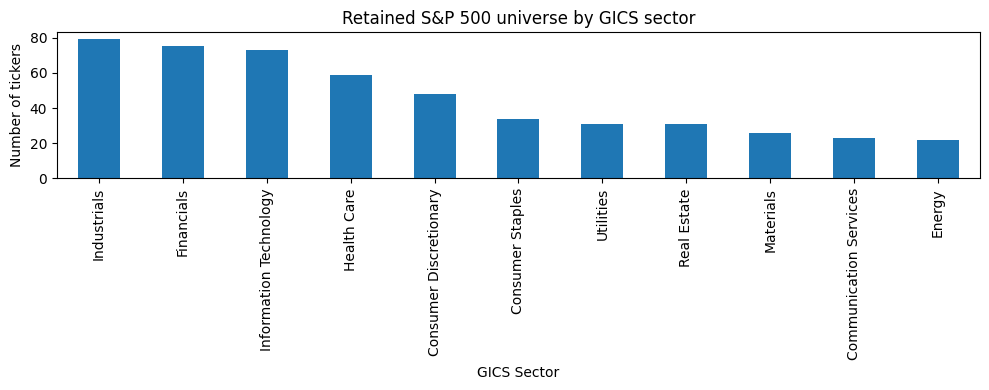

In [10]:
plt.figure(figsize=(10, 4))
sector_counts.plot(kind='bar')
plt.title('Retained S&P 500 universe by GICS sector')
plt.ylabel('Number of tickers')
plt.tight_layout()
plt.show()

## 3. Universe selection

A dynamic S\&P file contains many assets that enter later in the sample. For a clean conference analysis, it is often better to define a relatively stable universe.

Below, we use a coverage filter and an optional starting date.

In [11]:
# =============================
# 4. Universe selection
# =============================
START_DATE = '2014-01-01'      # conference-friendly stable period
MIN_COVERAGE = 0.90            # fraction of non-missing values after START_DATE

prices_sub = prices.loc[prices.index >= START_DATE].copy()
coverage_sub = prices_sub.notna().mean()
valid_tickers = coverage_sub[coverage_sub >= MIN_COVERAGE].index.tolist()

prices_f = prices_sub[valid_tickers].copy()
meta_f = meta.loc[valid_tickers].copy()

print('Selected universe size:', len(valid_tickers))
print('Date range:', prices_f.index.min().date(), 'to', prices_f.index.max().date())
print('Coverage min/median/max:',
      coverage_sub[valid_tickers].min(),
      coverage_sub[valid_tickers].median(),
      coverage_sub[valid_tickers].max())

Selected universe size: 460
Date range: 2014-01-02 to 2026-03-27
Coverage min/median/max: 0.9346766330841729 1.0 1.0


In [12]:
# Final sector composition
meta_f['GICS Sector'].value_counts().sort_values(ascending=False)

,count
GICS Sector,
Financials,71
Industrials,70
Information Technology,63
Health Care,56
Consumer Discretionary,45
Consumer Staples,32
Utilities,29
Real Estate,29
Materials,24


## 4. Prices and returns

The analysis uses **log returns**, which are standard for dependence estimation.

In [13]:
# =============================
# 5. Returns
# =============================
returns = np.log(prices_f).diff().dropna(how='all')
returns = returns.dropna(axis=1, how='all')

# Optional row cleaning: keep dates with broad coverage only
MIN_ROW_FRAC = 0.95
row_ok = returns.notna().mean(axis=1) >= MIN_ROW_FRAC
returns = returns.loc[row_ok].copy()

print('Returns shape:', returns.shape)
returns.head()

Returns shape: (3076, 460)


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-03,0.012552,-0.022211,0.006138,0.010667,-0.019360,0.003322,-0.002195,0.006674,0.004641,0.010835,...,-0.009095,0.002236,-0.009849,-0.000363,-0.002408,0.009034,0.006240,0.004327,0.007494,-0.009626
2014-01-06,-0.004932,0.005439,-0.037203,0.013112,-0.009463,-0.010621,-0.017736,-0.005660,0.002082,-0.011462,...,0.000228,-0.010264,-0.000715,-0.005469,0.001506,-0.001742,-0.000794,0.006456,-0.003365,-0.002186
2014-01-07,0.014199,-0.007177,0.001982,-0.007693,0.000359,0.012095,0.014519,0.005257,-0.009985,0.012081,...,0.002965,0.002897,0.028439,0.017039,0.014049,0.002902,0.013942,0.019752,0.010247,0.003745
2014-01-08,0.016230,0.006313,-0.002578,0.008969,-0.005936,0.007699,-0.001188,0.002417,-0.011501,-0.005338,...,0.001592,-0.009365,0.018585,-0.003962,-0.003270,-0.000580,-0.000392,0.024205,-0.000742,-0.011278
2014-01-09,0.000342,-0.012853,0.016933,0.001784,0.008980,0.009691,0.003221,-0.003829,-0.004733,0.003479,...,0.007022,0.005823,-0.002536,0.003962,-0.009776,0.004051,-0.019528,-0.009902,0.004627,0.006907


In [14]:
# Optional conservative fill inside already-selected series
# After the coverage filter, short gaps can be forward-filled/back-filled if needed.
returns = returns.ffill().bfill()
print('Any NaN left?', returns.isna().any().any())

Any NaN left? False


## 5. Helper functions

This block defines the main utilities for spectral analysis, eigenportfolios, MST construction, and community-sector alignment.

In [15]:
# =============================
# 6. Helper functions
# =============================

def correlation_distance(corr: pd.DataFrame) -> pd.DataFrame:
    """
    Mantegna correlation distance.
    d_ij = sqrt(2 * (1 - rho_ij))
    """
    dist = np.sqrt(np.clip(2 * (1 - corr), 0, None))
    return pd.DataFrame(dist, index=corr.index, columns=corr.columns)


def effective_rank_from_eigs(eigvals: np.ndarray) -> float:
    eigvals = np.asarray(eigvals, dtype=float)
    eigvals = eigvals[eigvals > 0]
    p = eigvals / eigvals.sum()
    entropy = -(p * np.log(p)).sum()
    return float(np.exp(entropy))


def participation_ratio(vec: np.ndarray) -> float:
    vec = np.asarray(vec, dtype=float)
    denom = np.sum(vec**4)
    if denom == 0:
        return np.nan
    return float(1.0 / denom)


def build_mst_from_corr(corr: pd.DataFrame) -> nx.Graph:
    dist = correlation_distance(corr)
    G = nx.Graph()
    tickers = corr.index.tolist()
    G.add_nodes_from(tickers)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            u, v = tickers[i], tickers[j]
            G.add_edge(u, v,
                       weight=float(dist.loc[u, v]),
                       corr=float(corr.loc[u, v]))
    T = nx.minimum_spanning_tree(G, weight='weight')
    return T


def ordinal_irreversibility(x: np.ndarray, m: int = 3) -> float:
    """
    Simple ordinal-pattern irreversibility based on forward vs reversed series.
    Kept here only as an auxiliary descriptor, not the core WEA contribution.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < m + 5:
        return np.nan

    perms = list(permutations(range(m)))
    perm_to_idx = {p: i for i, p in enumerate(perms)}

    def pattern_counts(series):
        counts = np.zeros(len(perms), dtype=float)
        for i in range(len(series) - m + 1):
            window = series[i:i+m]
            order = tuple(np.argsort(window, kind='mergesort'))
            counts[perm_to_idx[order]] += 1
        return counts

    c1 = pattern_counts(x)
    c2 = pattern_counts(x[::-1])
    p1 = (c1 + 1e-12) / (c1.sum() + 1e-12 * len(c1))
    p2 = (c2 + 1e-12) / (c2.sum() + 1e-12 * len(c2))
    return float(np.sum(p1 * np.log(p1 / p2)))


def leading_sector_contributions(weights: pd.Series, sector_map: pd.Series, top_n: int = 10) -> pd.DataFrame:
    df = pd.DataFrame({'weight': weights, 'sector': sector_map.reindex(weights.index)})
    df['abs_weight'] = df['weight'].abs()
    df = df.sort_values('abs_weight', ascending=False)
    return df.head(top_n)


def sector_weight_aggregation(weights: pd.Series, sector_map: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({'weight': weights, 'sector': sector_map.reindex(weights.index)})
    agg = df.groupby('sector')['weight'].sum().sort_values(key=np.abs, ascending=False)
    agg_abs = df.groupby('sector')['weight'].apply(lambda s: np.abs(s).sum()).sort_values(ascending=False)
    out = pd.DataFrame({'net_weight': agg, 'abs_weight': agg_abs}).sort_values('abs_weight', ascending=False)
    return out


def partition_from_sector_map(nodes, sector_map: pd.Series):
    return {n: sector_map.get(n, 'Unknown') for n in nodes}


def partition_from_communities(communities):
    mapping = {}
    for i, comm in enumerate(communities):
        for node in comm:
            mapping[node] = i
    return mapping


def alignment_scores(true_partition: dict, pred_partition: dict):
    common = sorted(set(true_partition).intersection(set(pred_partition)))
    y_true = [true_partition[n] for n in common]
    y_pred = [pred_partition[n] for n in common]
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    return {'ARI': ari, 'NMI': nmi, 'n_common': len(common)}

## 6. Static full-sample benchmark

Before the rolling analysis, it is useful to inspect one reference correlation matrix.

In [16]:
# =============================
# 7. Static full-sample benchmark
# =============================
corr_full = returns.corr()

# Eigen-decomposition (ascending order from eigh, so reverse)
eigvals_full, eigvecs_full = eigh(corr_full.values)
order = np.argsort(eigvals_full)[::-1]
eigvals_full = eigvals_full[order]
eigvecs_full = eigvecs_full[:, order]

print('Top 10 eigenvalues:')
print(np.round(eigvals_full[:10], 4))
print('Effective rank:', round(effective_rank_from_eigs(eigvals_full), 4))

Top 10 eigenvalues:
[162.1394  24.5447  16.7746   8.6435   6.7742   6.4664   5.373    4.5383
   4.1737   4.0279]
Effective rank: 59.8355


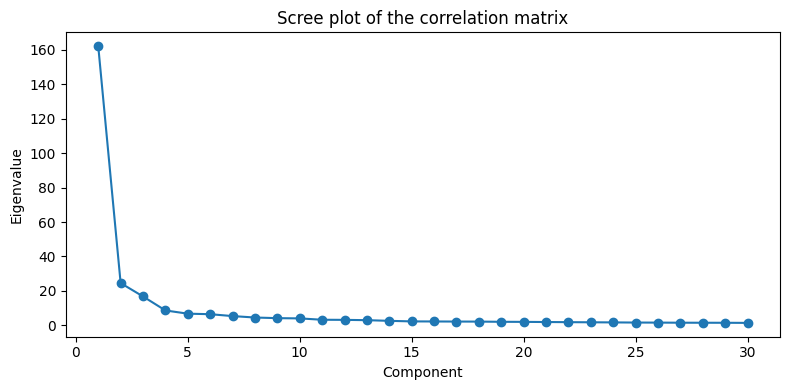

In [18]:
n = min(30, len(eigvals_full))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n + 1), eigvals_full[:n], marker='o')
plt.title('Scree plot of the correlation matrix')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.tight_layout()
plt.show()

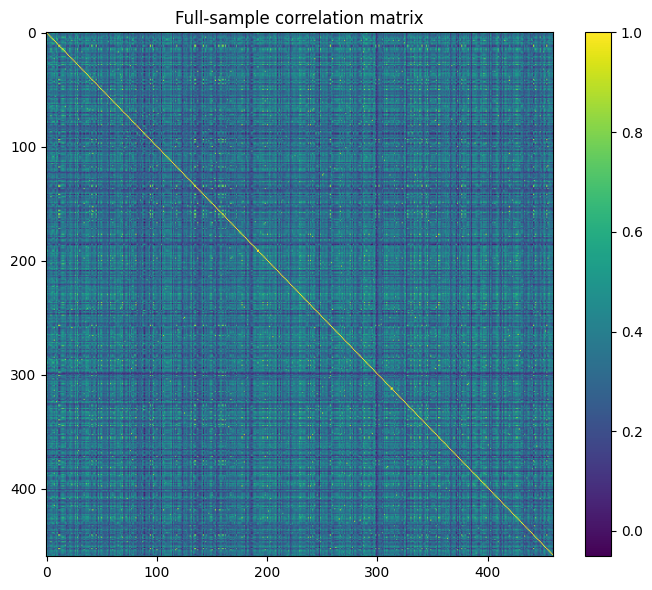

In [19]:
plt.figure(figsize=(7, 6))
plt.imshow(corr_full.values, aspect='auto')
plt.title('Full-sample correlation matrix')
plt.colorbar()
plt.tight_layout()
plt.show()

## 7. Full-sample eigenportfolios

The first eigenvector usually corresponds to the **market mode**. Higher eigenvectors often reveal sector contrasts or mesoscopic structure.

In [21]:
# =============================
# 8. Full-sample eigenportfolios
# =============================
sector_map = meta_f['GICS Sector']
subindustry_map = meta_f['GICS Sub-Industry']

for k in [0, 1, 2]:
    weights = pd.Series(eigvecs_full[:, k], index=corr_full.index)
    agg = sector_weight_aggregation(weights, sector_map)
    print(f'Eigenportfolio PC{k+1}: sector aggregation')
    display(agg.head(10))

Eigenportfolio PC1: sector aggregation


,net_weight,abs_weight
sector,,
Financials,-3.832595,3.832595
Industrials,-3.587349,3.587349
Information Technology,-2.868499,2.868499
Health Care,-2.266446,2.266446
Consumer Discretionary,-2.040437,2.040437
Real Estate,-1.389741,1.389741
Utilities,-1.163903,1.163903
Materials,-1.116798,1.116798
Consumer Staples,-1.101349,1.101349


Eigenportfolio PC2: sector aggregation


,net_weight,abs_weight
sector,,
Utilities,3.116270,3.126185
Financials,-0.773287,2.192450
Information Technology,-2.085911,2.174362
Consumer Staples,1.797375,1.817554
Industrials,-0.826778,1.782264
Real Estate,1.412543,1.524520
Consumer Discretionary,-0.823864,1.207279
Health Care,0.804914,1.130346
Energy,-0.716513,0.716513


Eigenportfolio PC3: sector aggregation


,net_weight,abs_weight
sector,,
Information Technology,-3.448688,3.482969
Financials,1.875558,3.238932
Health Care,-1.945097,2.224466
Energy,1.670206,1.670206
Industrials,0.218571,1.629352
Consumer Discretionary,-0.308899,1.296301
Real Estate,0.373828,1.158782
Consumer Staples,-0.168770,0.844765
Communication Services,-0.354730,0.742147


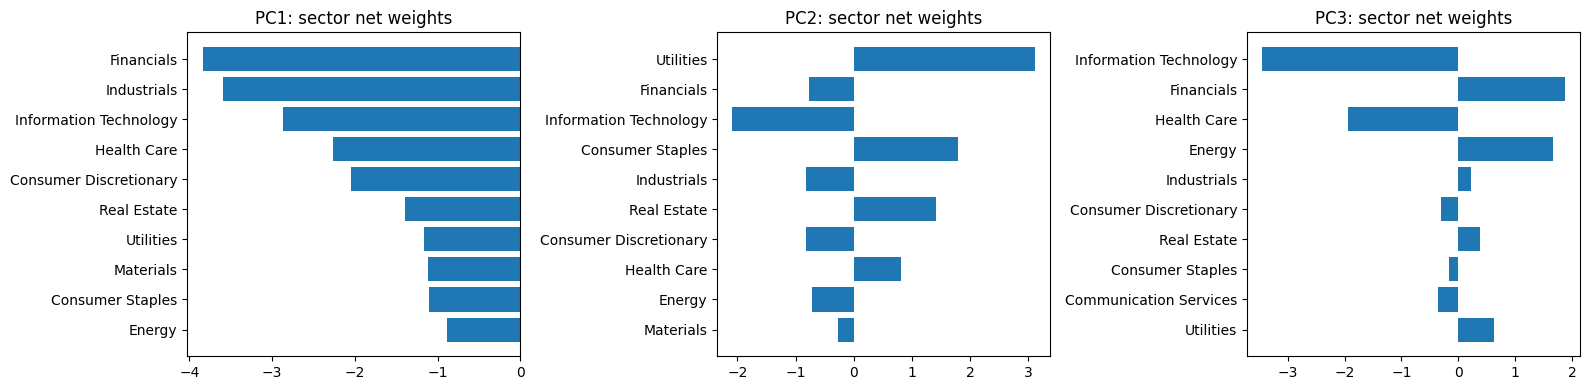

In [51]:
# Plot aggregated sector contributions for the first 3 eigenvectors
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, k in zip(axes, [0, 1, 2]):
    weights = pd.Series(eigvecs_full[:, k], index=corr_full.index)
    agg = sector_weight_aggregation(weights, sector_map).head(10)
    ax.barh(agg.index[::-1], agg['net_weight'][::-1])
    ax.set_title(f'PC{k+1}: sector net weights')
plt.tight_layout()
plt.show()

In [22]:
# Top individual loadings for the first three eigenvectors
for k in [0, 1, 2]:
    weights = pd.Series(eigvecs_full[:, k], index=corr_full.index)
    top_loads = leading_sector_contributions(weights, sector_map, top_n=12)
    print(f'Top loadings in PC{k+1}')
    display(top_loads)

Top loadings in PC1


,weight,sector,abs_weight
AMP,-0.065293,Financials,0.065293
BLK,-0.063396,Financials,0.063396
PRU,-0.062942,Financials,0.062942
PFG,-0.062886,Financials,0.062886
PH,-0.062843,Industrials,0.062843
AME,-0.062793,Industrials,0.062793
ITW,-0.062701,Industrials,0.062701
HON,-0.062264,Industrials,0.062264
DOV,-0.061559,Industrials,0.061559
MS,-0.061208,Financials,0.061208


Top loadings in PC2


,weight,sector,abs_weight
ED,0.151066,Utilities,0.151066
WEC,0.146064,Utilities,0.146064
CMS,0.145414,Utilities,0.145414
DUK,0.139937,Utilities,0.139937
AEP,0.139343,Utilities,0.139343
LNT,0.137701,Utilities,0.137701
XEL,0.137591,Utilities,0.137591
AEE,0.135067,Utilities,0.135067
SO,0.134639,Utilities,0.134639
AWK,0.131492,Utilities,0.131492


Top loadings in PC3


,weight,sector,abs_weight
NOW,-0.112608,Information Technology,0.112608
ADBE,-0.108702,Information Technology,0.108702
CDNS,-0.108266,Information Technology,0.108266
SNPS,-0.103346,Information Technology,0.103346
SLB,0.100995,Energy,0.100995
XOM,0.099405,Energy,0.099405
AMZN,-0.098862,Consumer Discretionary,0.098862
IDXX,-0.098586,Health Care,0.098586
TYL,-0.097214,Information Technology,0.097214
NVDA,-0.096238,Information Technology,0.096238


## 8. Full-sample network benchmark (MST)

The MST is a filtered representation of the dependence structure. It is useful for visualization, centrality, and sector organization.

In [23]:
# =============================
# 9. Full-sample MST and centrality
# =============================
T_full = build_mst_from_corr(corr_full)

print('MST nodes:', T_full.number_of_nodes())
print('MST edges:', T_full.number_of_edges())

MST nodes: 460
MST edges: 459


In [27]:
# Add sector metadata to graph nodes
for n in T_full.nodes():
    T_full.nodes[n]['sector'] = sector_map.get(n, 'Unknown')

# Centrality measures
mst_degree = pd.Series(dict(T_full.degree())).sort_values(ascending=False)
mst_betweenness = pd.Series(nx.betweenness_centrality(T_full)).sort_values(ascending=False)

centrality_table = pd.DataFrame({
    'degree': mst_degree,
    'betweenness': mst_betweenness.reindex(mst_degree.index),
    'sector': sector_map.reindex(mst_degree.index)
}).sort_values(['degree', 'betweenness'], ascending=False)

centrality_table.head(15)

,degree,betweenness,sector
PH,15,0.598120,Industrials
ITW,14,0.218407,Industrials
MCO,12,0.246587,Financials
AMP,11,0.655193,Financials
PRU,11,0.554490,Financials
TEL,8,0.233344,Information Technology
DTE,8,0.224858,Utilities
CMS,8,0.199703,Utilities
ADI,8,0.191312,Information Technology
MPWR,8,0.156035,Information Technology


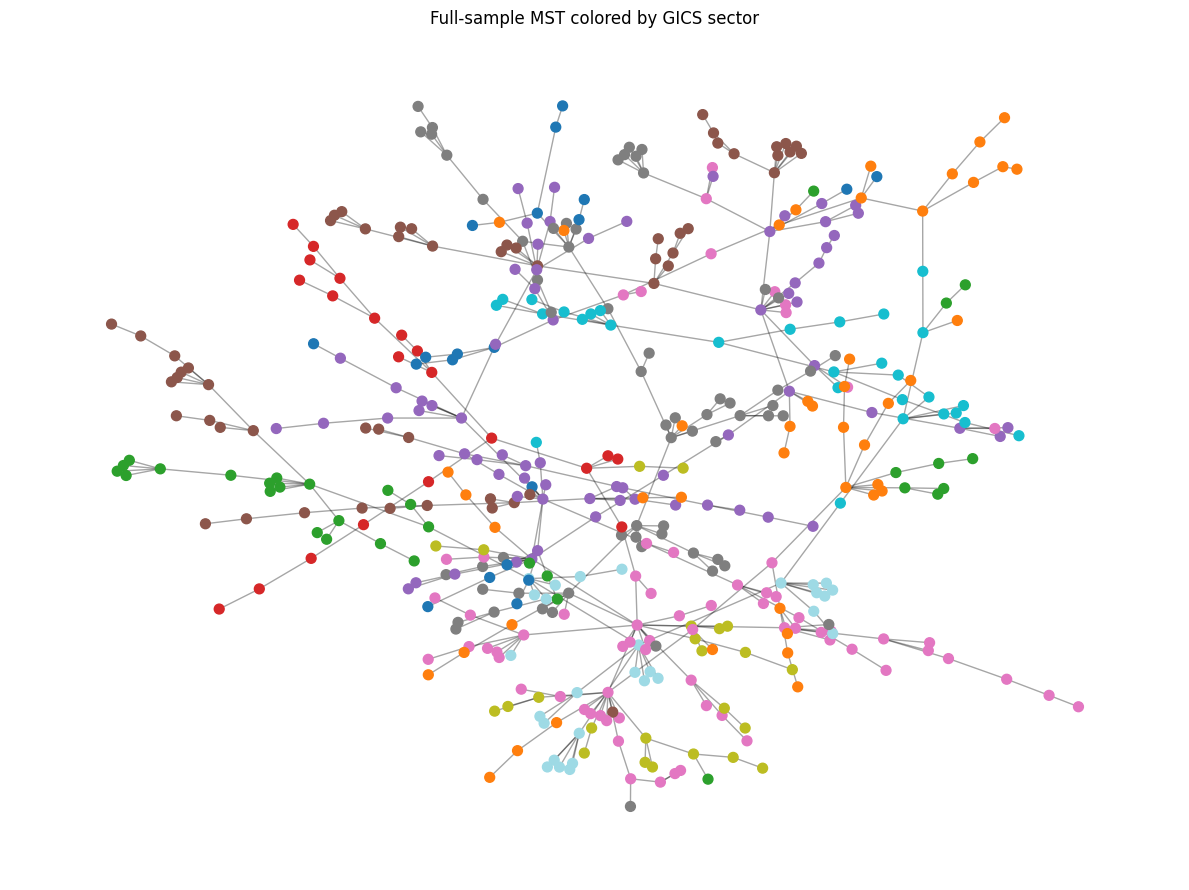

In [28]:
# Visualize the full-sample MST colored by sector
sector_list = sorted(sector_map.unique())
sector_to_color = {s: i for i, s in enumerate(sector_list)}
node_colors = [sector_to_color.get(T_full.nodes[n].get('sector', 'Unknown'), 0) for n in T_full.nodes()]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(T_full, seed=42)
nx.draw_networkx_nodes(T_full, pos, node_size=50, node_color=node_colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(T_full, pos, alpha=0.35)
plt.title('Full-sample MST colored by GICS sector')
plt.axis('off')
plt.tight_layout()
plt.show()

In [29]:
# Community detection on the MST
communities = list(nx.community.greedy_modularity_communities(T_full))
comm_partition = partition_from_communities(communities)
sector_partition = partition_from_sector_map(T_full.nodes(), sector_map)

scores = alignment_scores(sector_partition, comm_partition)
print('Community-sector alignment on full-sample MST:')
print(scores)
print('Number of communities:', len(communities))

Community-sector alignment on full-sample MST:
{'ARI': 0.2795248471474837, 'NMI': np.float64(0.5530788253295537), 'n_common': 460}
Number of communities: 20


## 9. Rolling analysis

This is the main dynamic block for the WEA paper.

For each rolling window, we compute:

- correlation matrix
- top eigenvalues
- effective rank
- average absolute correlation
- market mode concentration (IPR / participation ratio)
- PC1-based market mode series
- optional ordinal irreversibility of the market mode
- MST centralization statistics
- community-sector alignment

In [30]:
# =============================
# 10. Rolling parameters
# =============================
WINDOW = 252          # roughly one trading year
STEP = 5              # weekly shift
TOP_K = 5             # number of leading eigenvalues stored
USE_ORDINAL_IRR = True

print('WINDOW =', WINDOW)
print('STEP   =', STEP)

WINDOW = 252
STEP   = 5


In [31]:
# =============================
# 11. Rolling analysis engine
# =============================
results = []
eigenvectors_by_window = {}
sector_weights_by_window = {}
mst_snapshots = {}

ret = returns.copy()
dates = ret.index

total_windows = 0
for start in range(0, len(ret) - WINDOW + 1, STEP):
    end = start + WINDOW
    win = ret.iloc[start:end].copy()
    date_end = win.index[-1]

    # Correlation matrix
    corr = win.corr()
    corr = corr.replace([np.inf, -np.inf], np.nan)
    corr = corr.fillna(0.0)
    np.fill_diagonal(corr.values, 1.0)

    # Spectral decomposition
    eigvals, eigvecs = eigh(corr.values)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    lambda_max = float(eigvals[0])
    avg_abs_corr = float(np.mean(np.abs(corr.values[np.triu_indices_from(corr.values, k=1)])))
    eff_rank = effective_rank_from_eigs(eigvals)
    pr_pc1 = participation_ratio(eigvecs[:, 0])

    # Market mode series: PC1 scores inside the window
    pca = PCA(n_components=1)
    pc1_scores = pca.fit_transform(win.values).ravel()
    irr_ord = ordinal_irreversibility(pc1_scores, m=3) if USE_ORDINAL_IRR else np.nan

    # MST block
    T = build_mst_from_corr(corr)
    deg_series = pd.Series(dict(T.degree()))
    bet_series = pd.Series(nx.betweenness_centrality(T))
    max_degree = float(deg_series.max())
    avg_degree = float(deg_series.mean())
    avg_betweenness = float(bet_series.mean())
    max_betweenness = float(bet_series.max())

    # Communities vs sectors
    comms = list(nx.community.greedy_modularity_communities(T))
    comm_partition = partition_from_communities(comms)
    sector_partition = partition_from_sector_map(T.nodes(), sector_map)
    align = alignment_scores(sector_partition, comm_partition)

    row = {
        'date': date_end,
        'lambda_max': lambda_max,
        'avg_abs_corr': avg_abs_corr,
        'effective_rank': eff_rank,
        'participation_ratio_pc1': pr_pc1,
        'irr_ordinal_pc1': irr_ord,
        'mst_max_degree': max_degree,
        'mst_avg_degree': avg_degree,
        'mst_avg_betweenness': avg_betweenness,
        'mst_max_betweenness': max_betweenness,
        'n_communities': len(comms),
        'sector_alignment_ARI': align['ARI'],
        'sector_alignment_NMI': align['NMI'],
    }

    for k in range(TOP_K):
        row[f'eig_{k+1}'] = float(eigvals[k])

    results.append(row)
    total_windows += 1

    # Store selected objects for later interpretation
    eigenvectors_by_window[date_end] = pd.DataFrame(
        eigvecs[:, :TOP_K], index=corr.index,
        columns=[f'PC{k+1}' for k in range(TOP_K)]
    )

    sector_weights_by_window[date_end] = {
        f'PC{k+1}': sector_weight_aggregation(
            pd.Series(eigvecs[:, k], index=corr.index), sector_map
        ) for k in range(TOP_K)
    }

    # Keep a few MST snapshots only every ~50 windows to avoid memory explosion
    if total_windows % 50 == 0:
        mst_snapshots[date_end] = T

rolling_df = pd.DataFrame(results).set_index('date').sort_index()
print('Rolling results shape:', rolling_df.shape)
rolling_df.head()

Rolling results shape: (565, 17)


,lambda_max,avg_abs_corr,effective_rank,participation_ratio_pc1,irr_ordinal_pc1,mst_max_degree,mst_avg_degree,mst_avg_betweenness,mst_max_betweenness,n_communities,sector_alignment_ARI,sector_alignment_NMI,eig_1,eig_2,eig_3,eig_4,eig_5
date,,,,,,,,,,,,,,,,,
2015-01-02,148.581140,0.301144,50.289563,372.270981,0.031314,22.0,1.995652,0.018456,0.690175,22,0.229634,0.490049,148.581140,24.236690,12.413911,9.995730,7.481909
2015-01-09,153.734943,0.312127,47.788059,374.652647,0.019992,22.0,1.995652,0.018493,0.722075,23,0.226025,0.475169,153.734943,24.079717,12.601705,10.323391,7.378661
2015-01-16,153.457862,0.311377,47.767741,373.950301,0.019992,24.0,1.995652,0.016328,0.732626,22,0.204568,0.465737,153.457862,24.483826,12.659044,10.389157,7.459401
2015-01-26,150.472923,0.305180,48.975675,373.239612,0.021812,23.0,1.995652,0.016892,0.672365,25,0.188827,0.466002,150.472923,24.425312,13.186725,10.497805,7.753471
2015-02-02,151.892736,0.308580,48.153256,374.649272,0.022184,22.0,1.995652,0.017026,0.694247,21,0.252710,0.498561,151.892736,24.560642,13.268479,10.538414,7.755940


In [32]:
rolling_df.describe().T

,count,mean,std,min,25%,50%,75%,max
lambda_max,565.0,154.277584,4.410148e+01,71.850529,125.151825,149.015274,178.966008,263.025664
avg_abs_corr,565.0,0.316664,9.556931e-02,0.146011,0.252253,0.302038,0.371128,0.556972
effective_rank,565.0,43.633434,1.641491e+01,12.462073,33.766528,42.579309,54.589606,89.285346
participation_ratio_pc1,565.0,368.506533,3.210914e+01,277.750556,345.228033,365.980880,396.264629,427.681058
irr_ordinal_pc1,565.0,0.024011,1.651834e-02,0.001181,0.010515,0.020362,0.034349,0.081167
mst_max_degree,565.0,15.536283,3.568108e+00,8.000000,13.000000,15.000000,18.000000,30.000000
mst_avg_degree,565.0,1.995652,8.889655e-16,1.995652,1.995652,1.995652,1.995652,1.995652
mst_avg_betweenness,565.0,0.025626,3.815155e-03,0.015925,0.023133,0.025446,0.028226,0.036637
mst_max_betweenness,565.0,0.665488,4.965131e-02,0.565050,0.629392,0.658247,0.693705,0.832653
n_communities,565.0,21.920354,1.212681e+00,18.000000,21.000000,22.000000,23.000000,26.000000


## 10. Regime labels

These dates can be adjusted depending on the narrative of the conference paper.

In [33]:
# =============================
# 12. Regime labeling
# =============================
COVID_START = pd.Timestamp('2020-03-11')
COVID_END = pd.Timestamp('2021-03-11')

def label_regime(dt):
    if dt < COVID_START:
        return 'Pre-COVID'
    elif dt <= COVID_END:
        return 'COVID'
    else:
        return 'Post-COVID'

rolling_df['regime'] = [label_regime(d) for d in rolling_df.index]
rolling_df['regime'].value_counts()

,count
regime,
Pre-COVID,261
Post-COVID,253
COVID,51


## 11. Main dynamic figures

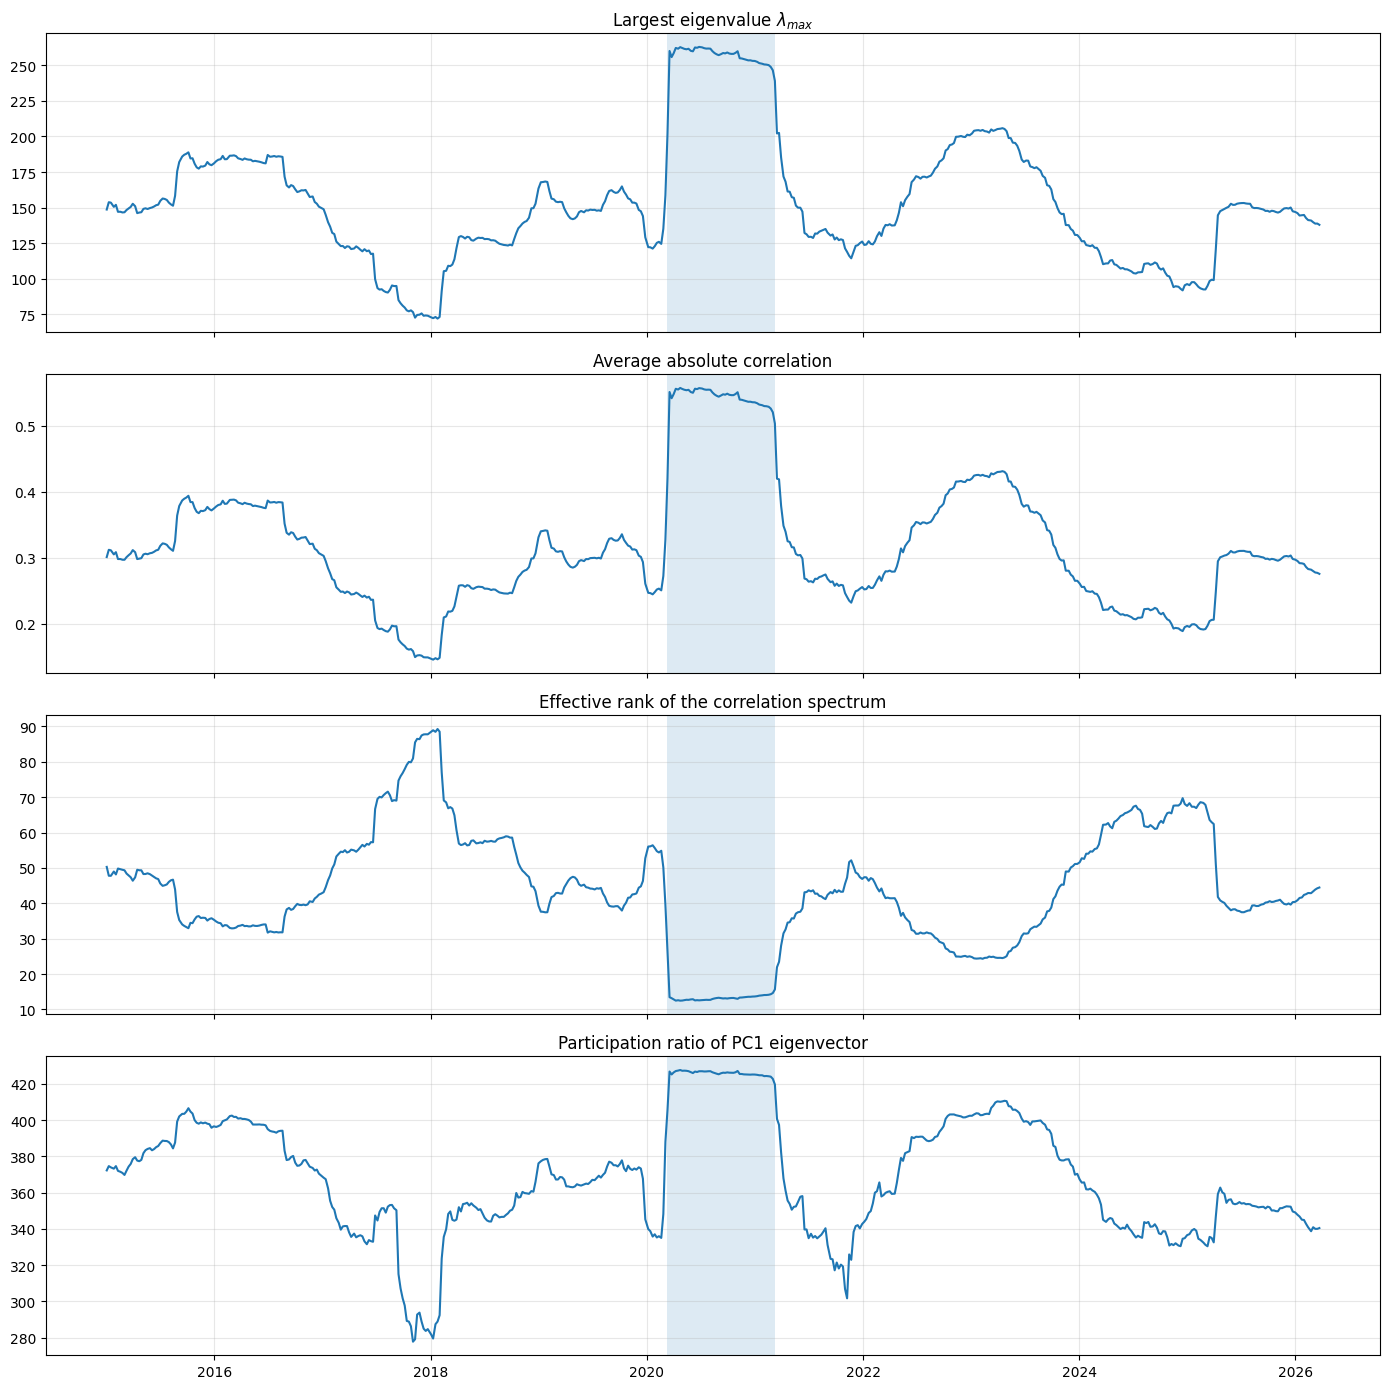

In [34]:
# =============================
# 13. Main time-series panel
# =============================
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(rolling_df.index, rolling_df['lambda_max'])
axes[0].set_title('Largest eigenvalue $\lambda_{max}$')

axes[1].plot(rolling_df.index, rolling_df['avg_abs_corr'])
axes[1].set_title('Average absolute correlation')

axes[2].plot(rolling_df.index, rolling_df['effective_rank'])
axes[2].set_title('Effective rank of the correlation spectrum')

axes[3].plot(rolling_df.index, rolling_df['participation_ratio_pc1'])
axes[3].set_title('Participation ratio of PC1 eigenvector')

for ax in axes:
    ax.axvspan(COVID_START, COVID_END, alpha=0.15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

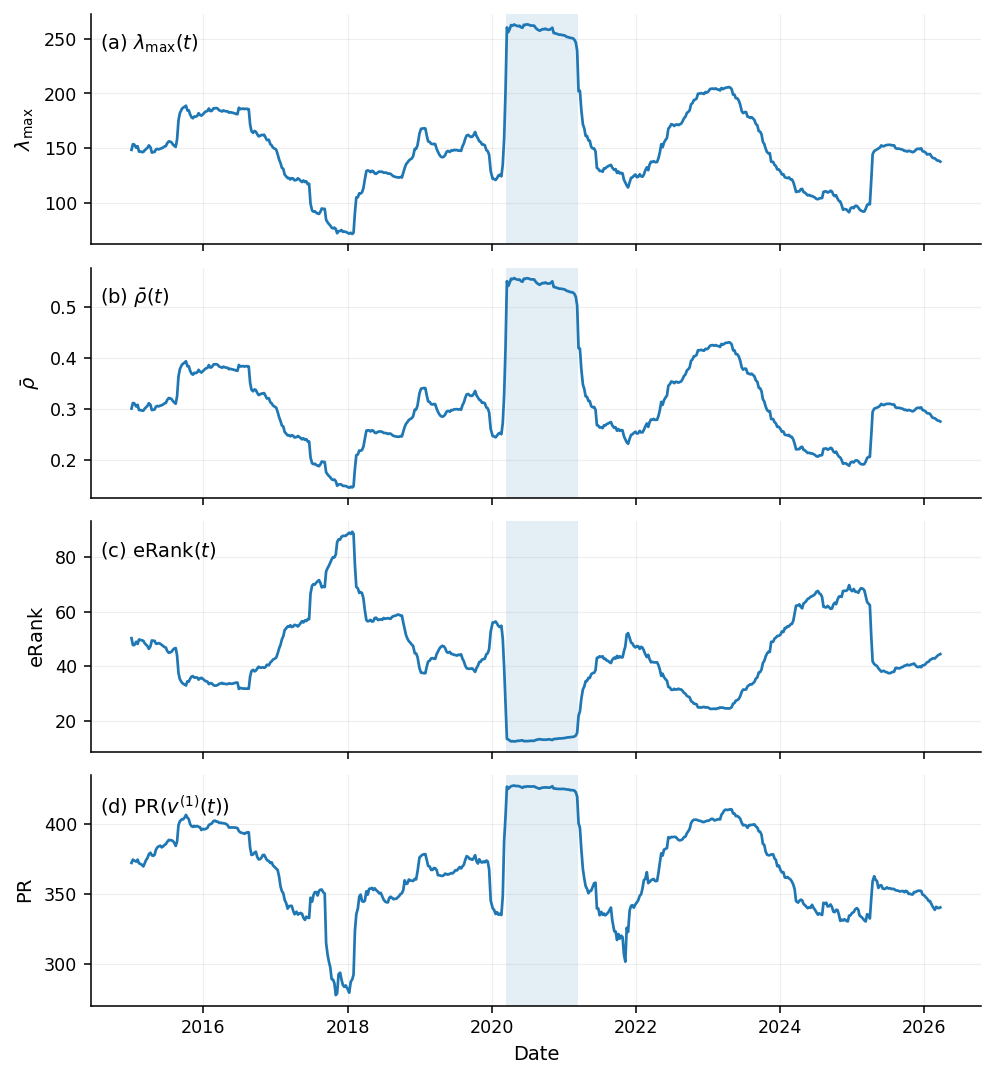

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Optional: cleaner matplotlib defaults
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 140
})

fig, axes = plt.subplots(
    4, 1, figsize=(8.2, 9.2), sharex=True,
    gridspec_kw={"hspace": 0.10}
)

series_specs = [
    ("lambda_max", r"(a) $\lambda_{\max}(t)$", r"$\lambda_{\max}$"),
    ("avg_abs_corr", r"(b) $\bar{\rho}(t)$", r"$\bar{\rho}$"),
    ("effective_rank", r"(c) $\mathrm{eRank}(t)$", r"$\mathrm{eRank}$"),
    ("participation_ratio_pc1", r"(d) $\mathrm{PR}(v^{(1)}(t))$", r"$\mathrm{PR}$")
]

for ax, (col, panel_label, ylab) in zip(axes, series_specs):
    ax.plot(
        rolling_df.index,
        rolling_df[col],
        linewidth=1.4
    )

    # COVID shading
    ax.axvspan(COVID_START, COVID_END, alpha=0.12)

    # Panel label inside each axis
    ax.text(
        0.01, 0.92, panel_label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    ax.set_ylabel(ylab)

    # Cleaner grid
    ax.grid(True, which="major", alpha=0.20, linewidth=0.6)

    # Remove top/right spines for cleaner style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# X-axis formatting
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Optional: add period label above shaded area only in first panel
# axes[0].text(
#     COVID_START + (COVID_END - COVID_START) / 2,
#     axes[0].get_ylim()[1] * 0.98,
#     "COVID-19 period",
#     ha="center",
#     va="top",
#     fontsize=9
# )

plt.tight_layout()

# Save for Springer submission
plt.savefig("fig_spectral_dynamics_snp500.pdf", dpi=400, bbox_inches="tight")
plt.savefig("fig_spectral_dynamics_snp500.png", dpi=400, bbox_inches="tight")
plt.show()

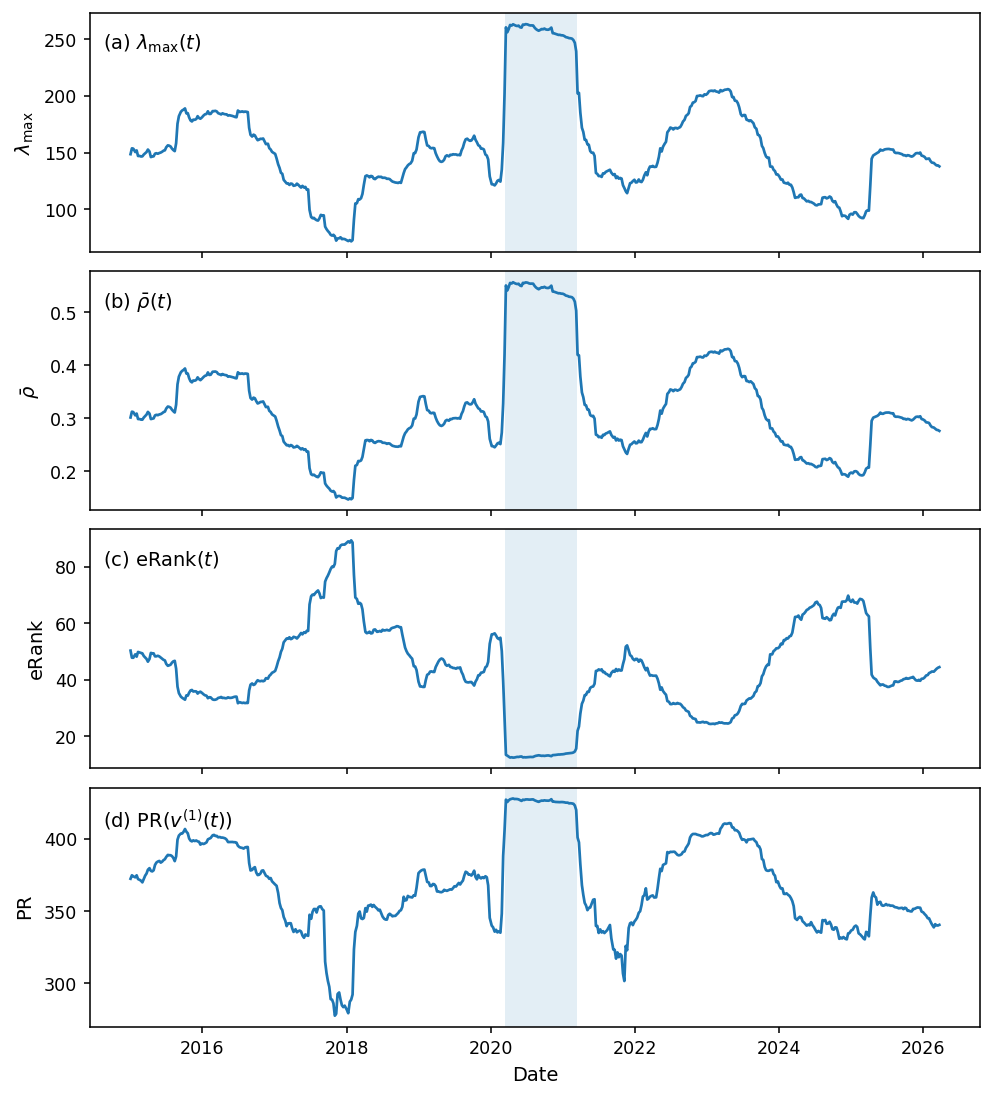

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# Springer/LNCS-style multi-panel figure
# Assumes:
#   - rolling_df is a pandas DataFrame indexed by dates
#   - columns:
#       'lambda_max'
#       'avg_abs_corr'
#       'effective_rank'
#       'participation_ratio_pc1'
#   - COVID_START and COVID_END are datetime-like
# --------------------------------------------------

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 140,
    "savefig.dpi": 400
})

fig, axes = plt.subplots(
    4, 1,
    figsize=(8.2, 9.4),
    sharex=True,
    gridspec_kw={"hspace": 0.08}
)

series_specs = [
    ("lambda_max", r"(a) $\lambda_{\max}(t)$", r"$\lambda_{\max}$"),
    ("avg_abs_corr", r"(b) $\bar{\rho}(t)$", r"$\bar{\rho}$"),
    ("effective_rank", r"(c) $\mathrm{eRank}(t)$", r"$\mathrm{eRank}$"),
    ("participation_ratio_pc1", r"(d) $\mathrm{PR}(v^{(1)}(t))$", r"$\mathrm{PR}$")
]

for ax, (col, panel_label, ylab) in zip(axes, series_specs):
    ax.plot(
        rolling_df.index,
        rolling_df[col],
        linewidth=1.4
    )

    # Shaded COVID period
    ax.axvspan(COVID_START, COVID_END, alpha=0.12)

    # Panel label inside axis
    ax.text(
        0.015, 0.92, panel_label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    # Axis label
    ax.set_ylabel(ylab)

    # No grid for cleaner Springer-style appearance
    ax.grid(False)

    # Full black frame around each subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    # Slightly thinner ticks
    ax.tick_params(width=0.8, length=3)

# Optional label for shaded period in first panel
# y0, y1 = axes[0].get_ylim()
# axes[0].text(
#     COVID_START + (COVID_END - COVID_START) / 2,
#     y1 - 0.04 * (y1 - y0),
#     "COVID-19",
#     ha="center",
#     va="top",
#     fontsize=9
# )

# X-axis formatting
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("fig_spectral_dynamics_snp500.png", bbox_inches="tight")
plt.savefig("fig_spectral_dynamics_snp500.pdf", bbox_inches="tight")

plt.show()

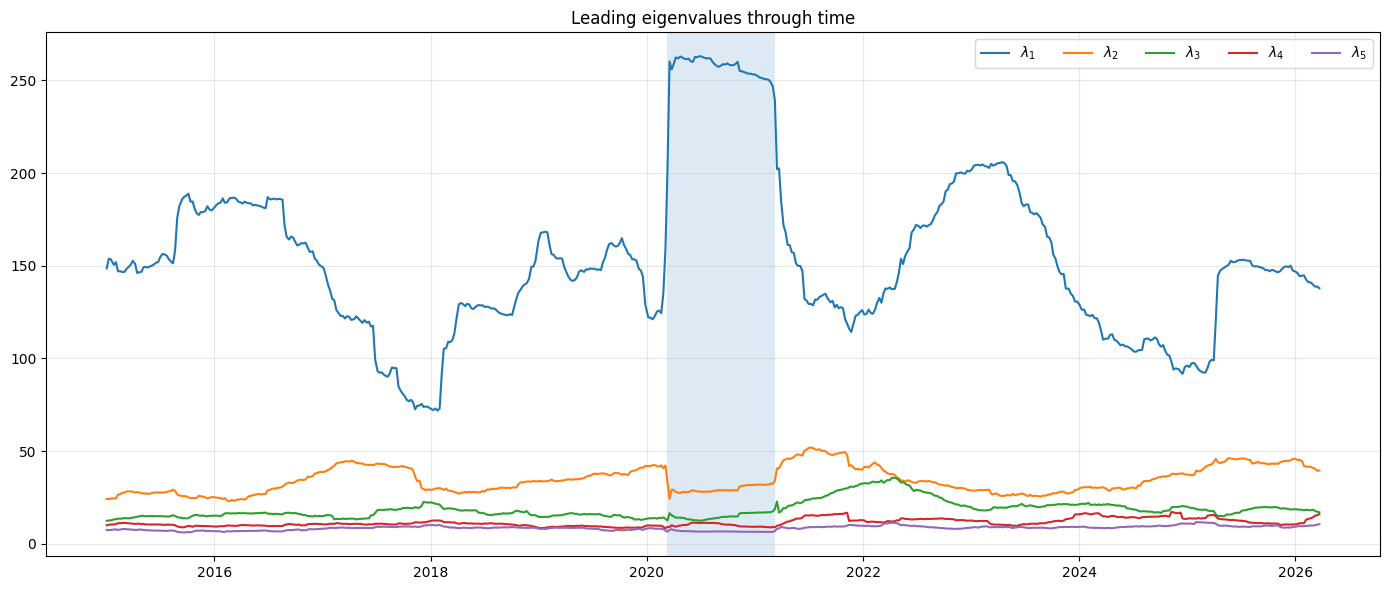

In [35]:
# Top eigenvalues over time
plt.figure(figsize=(14, 6))
for k in range(1, TOP_K + 1):
    plt.plot(rolling_df.index, rolling_df[f'eig_{k}'], label=f'$\lambda_{k}$')
plt.axvspan(COVID_START, COVID_END, alpha=0.15)
plt.title('Leading eigenvalues through time')
plt.legend(ncol=TOP_K)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

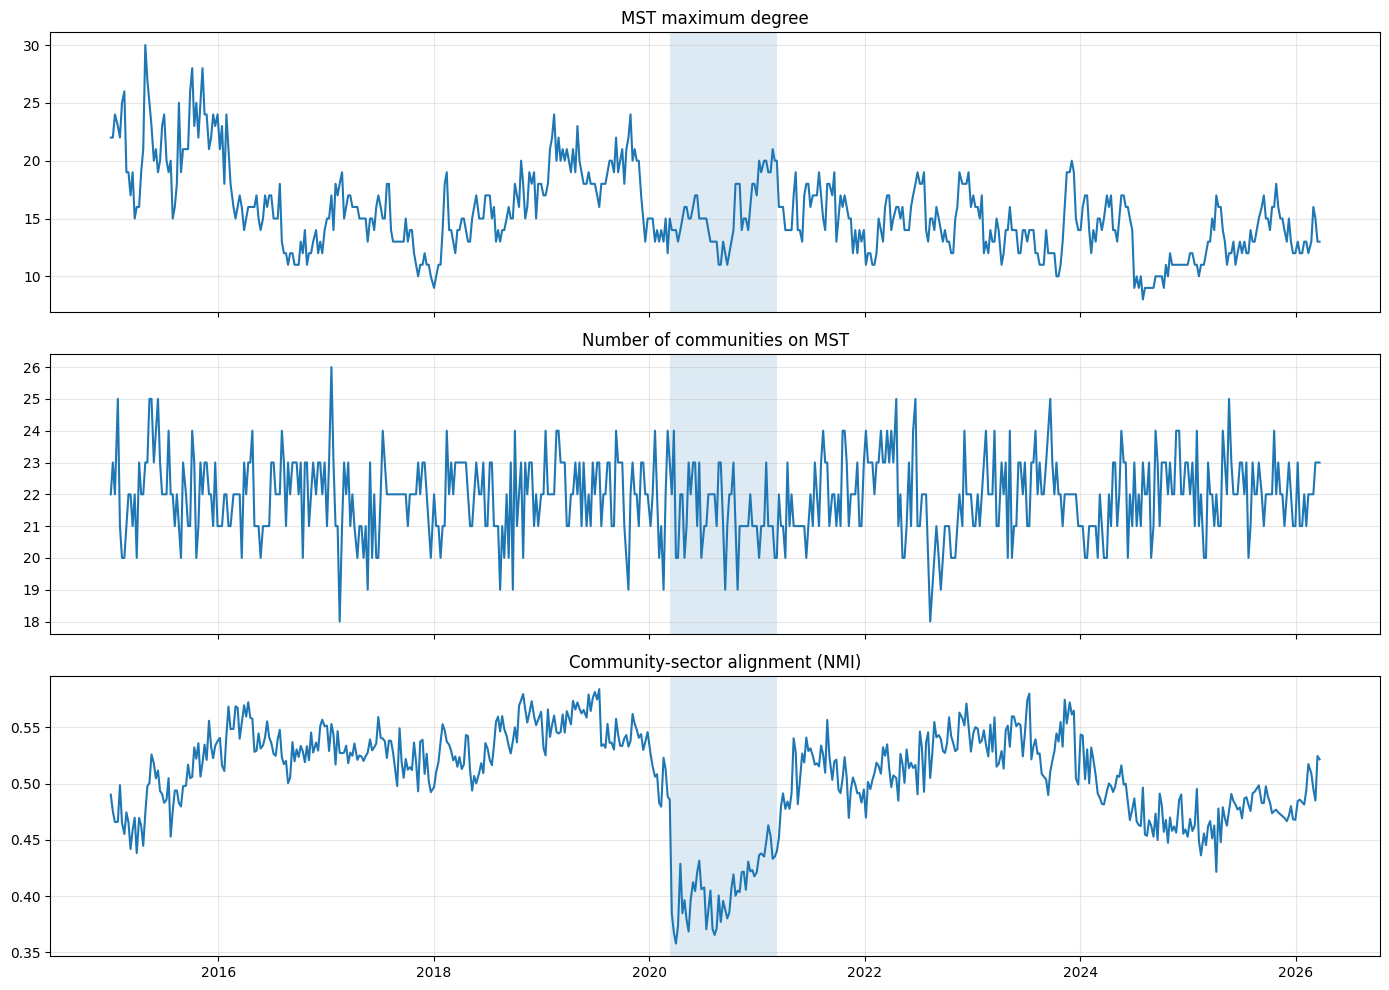

In [36]:
# Network/community metrics through time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(rolling_df.index, rolling_df['mst_max_degree'])
axes[0].set_title('MST maximum degree')

axes[1].plot(rolling_df.index, rolling_df['n_communities'])
axes[1].set_title('Number of communities on MST')

axes[2].plot(rolling_df.index, rolling_df['sector_alignment_NMI'])
axes[2].set_title('Community-sector alignment (NMI)')

for ax in axes:
    ax.axvspan(COVID_START, COVID_END, alpha=0.15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Regime summaries

These tables are useful for the results section of the conference paper.

In [37]:
# =============================
# 14. Regime summary tables
# =============================
summary_cols = [
    'lambda_max', 'avg_abs_corr', 'effective_rank', 'participation_ratio_pc1',
    'mst_max_degree', 'mst_max_betweenness', 'n_communities',
    'sector_alignment_ARI', 'sector_alignment_NMI'
]
if USE_ORDINAL_IRR:
    summary_cols.append('irr_ordinal_pc1')

regime_summary = rolling_df.groupby('regime')[summary_cols].agg(['mean', 'std', 'median'])
regime_summary

lambda_max                        avg_abs_corr            \
                  mean        std      median         mean       std   
regime                                                                 
COVID       256.156205   9.244722  258.464089     0.541716  0.020643   
Post-COVID  145.530298  32.310793  145.576812     0.297546  0.068981   
Pre-COVID   142.849437  30.809637  148.315608     0.291220  0.064640   

                     effective_rank                        \
              median           mean        std     median   
regime                                                      
COVID       0.546769      13.482174   1.949611  13.160110   
Post-COVID  0.295641      43.586887  13.322344  41.425553   
Pre-COVID   0.300024      49.570180  14.072571  46.678365   

           participation_ratio_pc1  ... n_communities sector_alignment_ARI  \
                              mean  ...        median                 mean   
regime                              ...                                      
COVID                   425.473438  ...          21.0             0.171057   
Post-COVID              362.214936  ...          22.0             0.239238   
Pre-COVID               363.473819  ...          22.0             0.267911   

                               sector_alignment_NMI                      \
                 std    median                 mean       std    median   
regime                                                                    
COVID       0.025967  0.169298             0.407457  0.027854  0.405552   
Post-COVID  0.031132  0.234425             0.504597  0.032017  0.502934   
Pre-COVID   0.030256  0.268600             0.528288  0.027977  0.532095   

           irr_ordinal_pc1                      
                      mean       std    median  
regime                                          
COVID             0.019881  0.013075  0.018621  
Post-COVID        0.027658  0.018246  0.021663  
Pre-COVID         0.021283  0.014580  0.019083  

[3 rows x 30 columns]

In [38]:
simple_regime_summary = rolling_df.groupby('regime')[summary_cols].mean().reset_index()
simple_regime_summary

,regime,lambda_max,avg_abs_corr,effective_rank,participation_ratio_pc1,mst_max_degree,mst_max_betweenness,n_communities,sector_alignment_ARI,sector_alignment_NMI,irr_ordinal_pc1
0,COVID,256.156205,0.541716,13.482174,425.473438,15.549020,0.649123,21.411765,0.171057,0.407457,0.019881
1,Post-COVID,145.530298,0.297546,43.586887,362.214936,13.988142,0.659026,21.960474,0.239238,0.504597,0.027658
2,Pre-COVID,142.849437,0.291220,49.570180,363.473819,17.034483,0.674951,21.980843,0.267911,0.528288,0.021283


## 13. Spectral scatter analysis

These plots help show the coupling between synchronization and dimensional collapse.

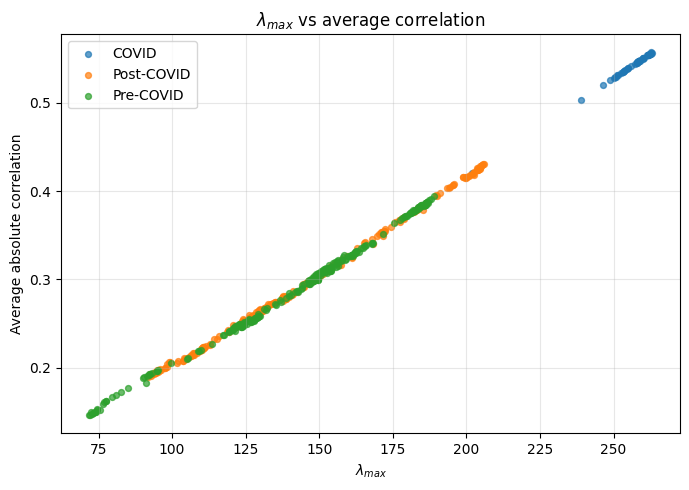

In [39]:
plt.figure(figsize=(7, 5))
for reg, g in rolling_df.groupby('regime'):
    plt.scatter(g['lambda_max'], g['avg_abs_corr'], s=18, alpha=0.7, label=reg)
plt.xlabel('$\lambda_{max}$')
plt.ylabel('Average absolute correlation')
plt.title('$\lambda_{max}$ vs average correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

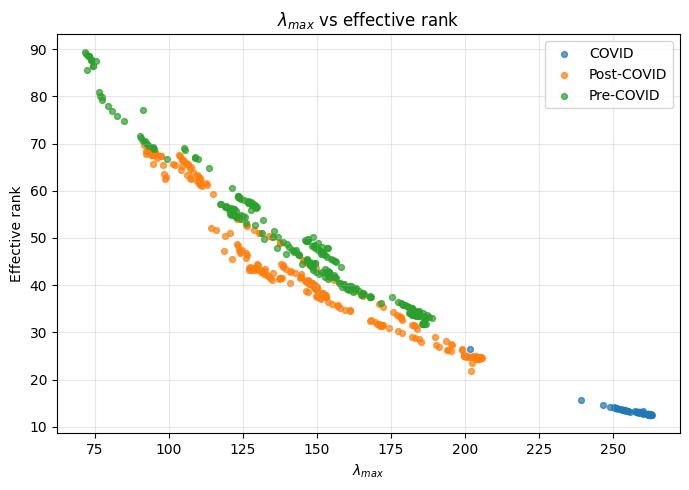

In [52]:
plt.figure(figsize=(7, 5))
for reg, g in rolling_df.groupby('regime'):
    plt.scatter(g['lambda_max'], g['effective_rank'], s=18, alpha=0.7, label=reg)
plt.xlabel('$\lambda_{max}$')
plt.ylabel('Effective rank')
plt.title('$\lambda_{max}$ vs effective rank')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Representative windows for eigenportfolios

We select representative dates from each regime and inspect the first eigenportfolios.

In [40]:
# =============================
# 15. Representative dates
# =============================
def nearest_available_date(target, available_index):
    target = pd.Timestamp(target)
    available = pd.Index(available_index)
    return available[np.argmin(np.abs(available - target))]

rep_dates = {
    'Pre-COVID': nearest_available_date('2019-06-30', rolling_df.index),
    'COVID': nearest_available_date('2020-06-30', rolling_df.index),
    'Post-COVID': nearest_available_date('2023-06-30', rolling_df.index),
}
rep_dates

{'Pre-COVID': Timestamp('2019-07-01 00:00:00'),
 'COVID': Timestamp('2020-06-26 00:00:00'),
 'Post-COVID': Timestamp('2023-06-28 00:00:00')}

In [43]:
for label, dt in rep_dates.items():
    print(f'===== {label} | representative date: {dt.date()} =====')
    eig_df = eigenvectors_by_window[dt]
    for pc in ['PC1', 'PC2', 'PC3']:
        weights = eig_df[pc]
        agg = sector_weight_aggregation(weights, sector_map)
        print(f'{pc}: top sector contributions')
        display(agg.head(8))

===== Pre-COVID | representative date: 2019-07-01 =====
PC1: top sector contributions


,net_weight,abs_weight
sector,,
Industrials,-3.759972,3.759972
Financials,-3.675229,3.675229
Information Technology,-3.316492,3.316492
Health Care,-2.604096,2.604096
Consumer Discretionary,-1.942841,1.942841
Materials,-1.074690,1.074690
Energy,-0.939372,0.939372
Real Estate,-0.936973,0.936973


PC2: top sector contributions


,net_weight,abs_weight
sector,,
Utilities,-3.393483,3.393483
Real Estate,-2.550913,2.582216
Financials,0.705587,1.793053
Consumer Staples,-1.536915,1.536915
Information Technology,1.241057,1.306646
Industrials,0.490245,1.055327
Consumer Discretionary,0.520734,0.891945
Health Care,-0.697028,0.885956


PC3: top sector contributions


...

,net_weight,abs_weight
sector,,
Industrials,-3.557049,3.557049
Financials,-3.511856,3.511856
Information Technology,-3.062920,3.062920
Health Care,-2.166992,2.166992
Consumer Discretionary,-2.069289,2.069289
Real Estate,-1.498855,1.498855
Utilities,-1.297701,1.297701
Materials,-1.112394,1.112394


PC2: top sector contributions


,net_weight,abs_weight
sector,,
Utilities,-2.919401,2.919401
Information Technology,2.313486,2.544219
Financials,0.568830,1.897689
Health Care,-1.183279,1.870875
Consumer Staples,-1.732587,1.844984
Industrials,-0.098354,1.743286
Consumer Discretionary,1.040172,1.614652
Real Estate,-0.689357,0.865023


PC3: top sector contributions


,net_weight,abs_weight
sector,,
Financials,-2.560545,3.512632
Energy,-2.397817,2.397817
Information Technology,2.143379,2.229907
Industrials,-0.589932,2.032824
Health Care,0.441414,1.815382
Consumer Discretionary,0.548037,0.982840
Real Estate,0.799982,0.883688
Consumer Staples,-0.013344,0.852873


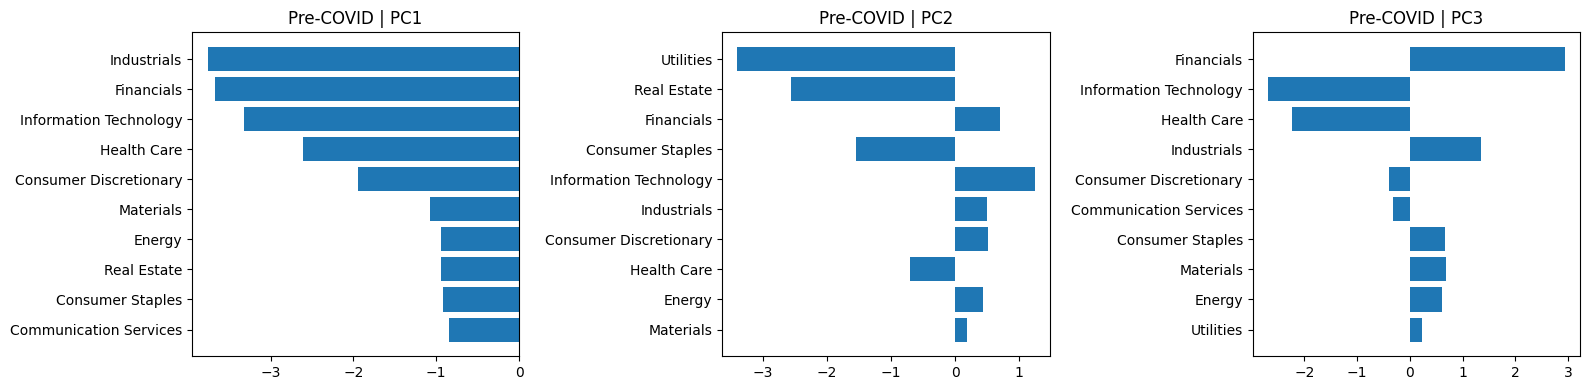

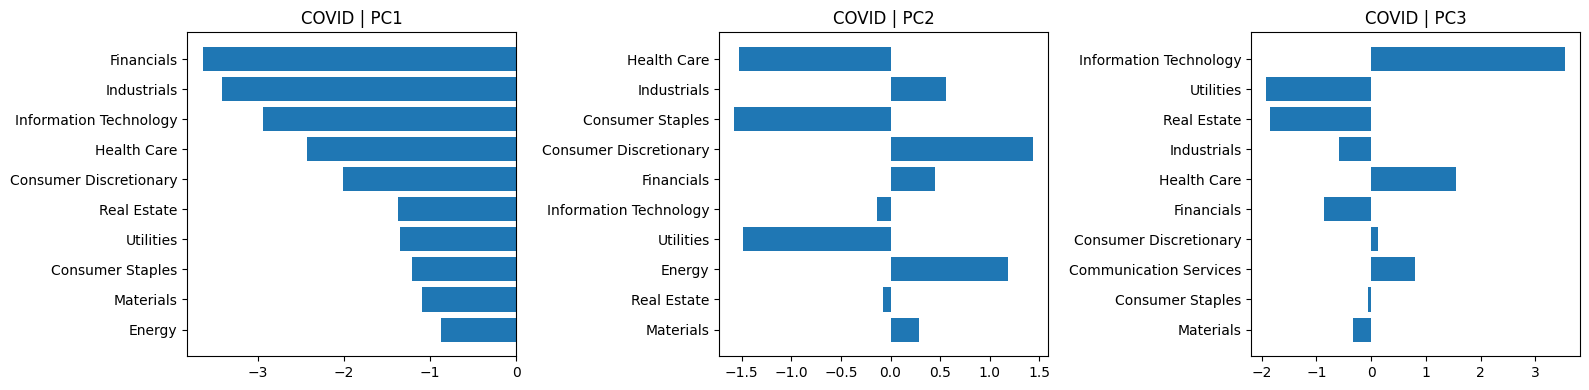

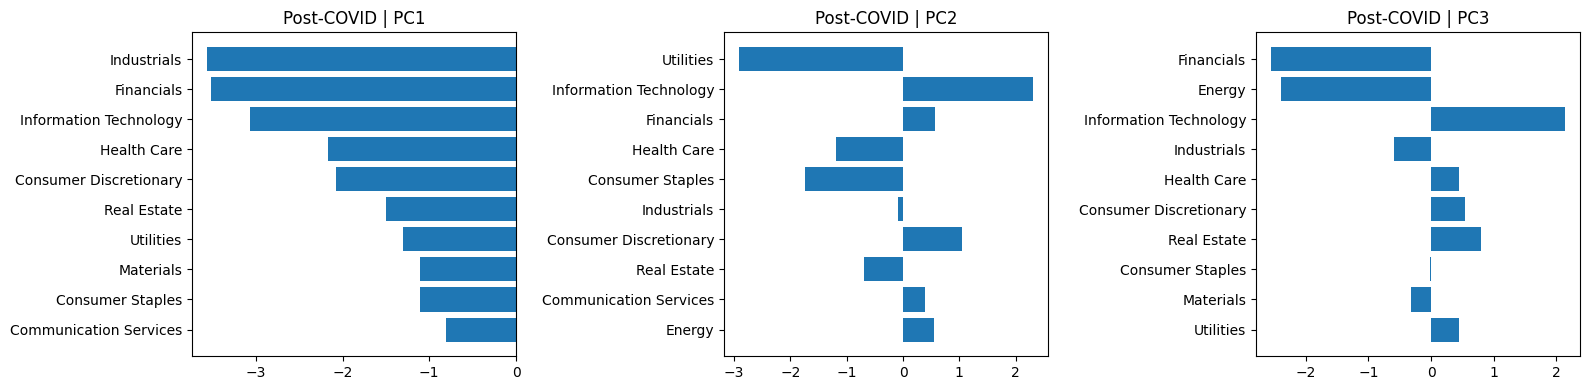

In [44]:
# Plot sector aggregates for representative windows
for label, dt in rep_dates.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    eig_df = eigenvectors_by_window[dt]
    for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
        agg = sector_weight_aggregation(eig_df[pc], sector_map).head(10)
        ax.barh(agg.index[::-1], agg['net_weight'][::-1])
        ax.set_title(f'{label} | {pc}')
    plt.tight_layout()
    plt.show()

## 15. Representative MST snapshots

For a conference paper, showing three snapshots is usually enough: one before COVID, one during COVID, and one after.

In [45]:
# =============================
# 16. Representative MST snapshots
# =============================
def mst_for_window_end(target_date):
    idx_dates = returns.index
    end_loc = idx_dates.get_indexer([target_date], method='nearest')[0]
    end_loc = max(end_loc, WINDOW)
    start_loc = end_loc - WINDOW
    win = returns.iloc[start_loc:end_loc].copy()
    corr = win.corr().fillna(0.0)
    np.fill_diagonal(corr.values, 1.0)
    T = build_mst_from_corr(corr)
    for n in T.nodes():
        T.nodes[n]['sector'] = sector_map.get(n, 'Unknown')
    return T

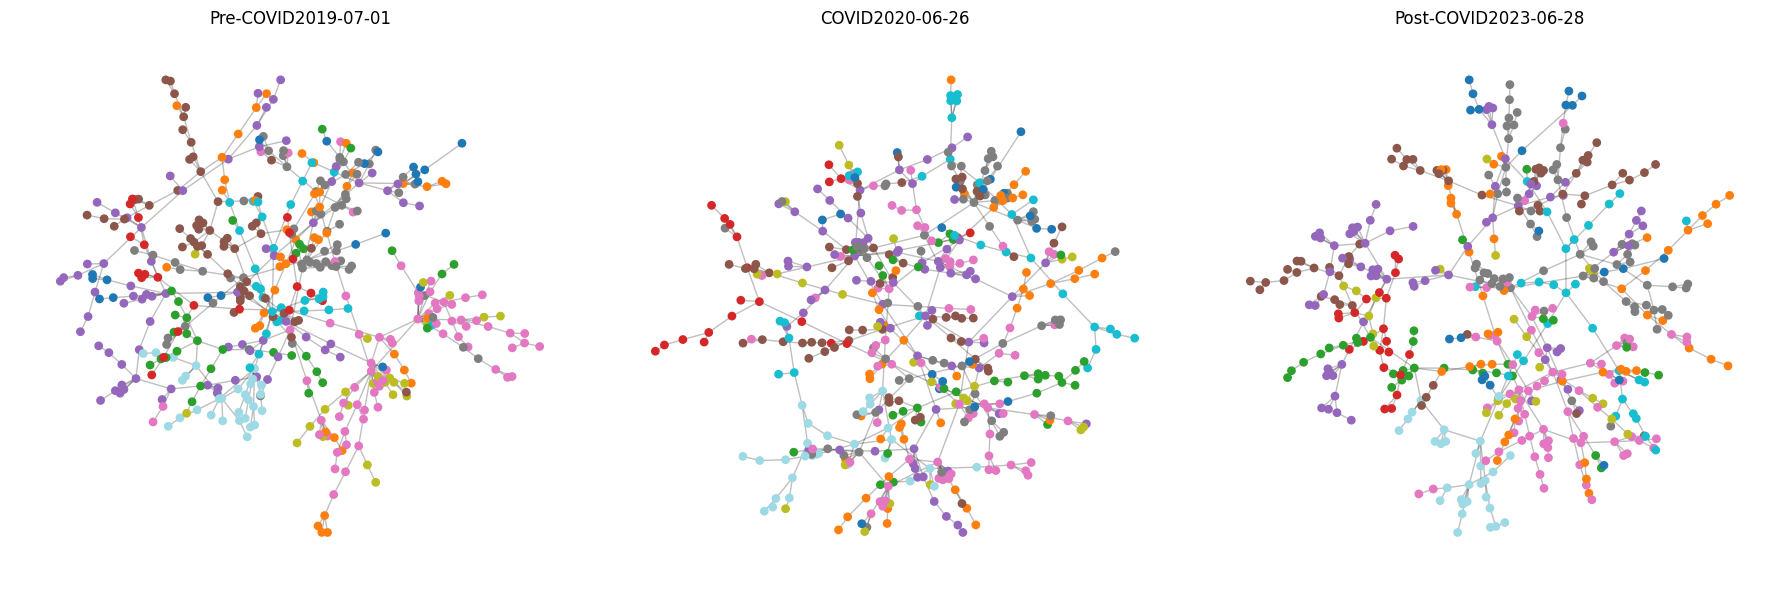

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (label, dt) in zip(axes, rep_dates.items()):
    T = mst_for_window_end(dt)
    pos = nx.spring_layout(T, seed=42)
    node_colors = [sector_to_color.get(T.nodes[n].get('sector', 'Unknown'), 0) for n in T.nodes()]
    nx.draw_networkx_nodes(T, pos, node_size=28, node_color=node_colors, cmap=plt.cm.tab20, ax=ax)
    nx.draw_networkx_edges(T, pos, alpha=0.25, ax=ax)
    ax.set_title(f'{label}{dt.date()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 16. Sector clustering from the correlation distance

This block complements the MST with a more classical clustering view.

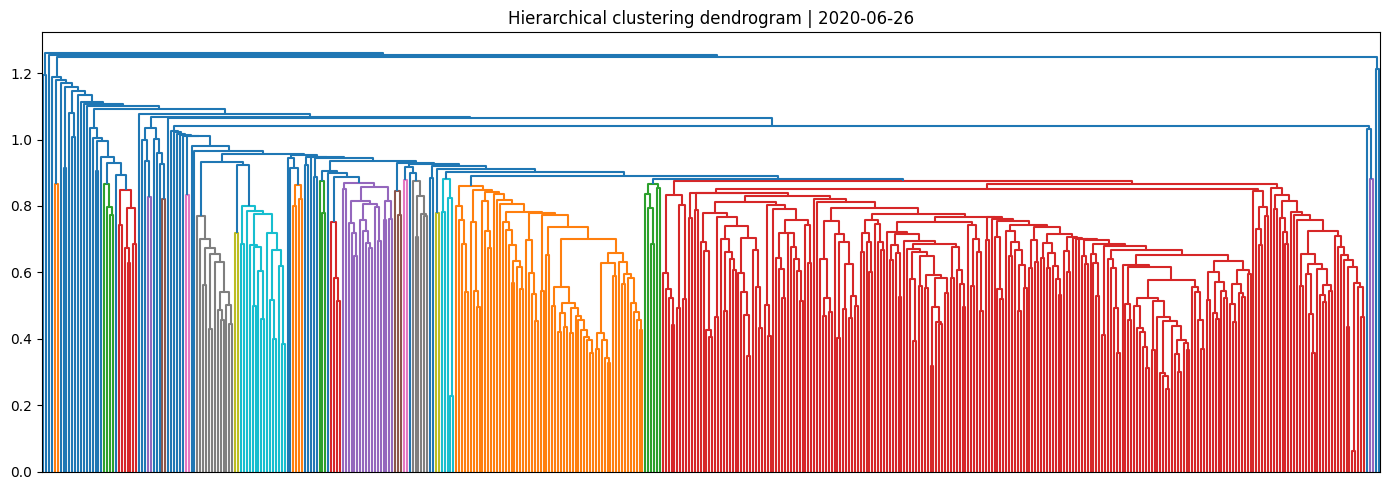

In [48]:
# =============================
# 17. Hierarchical clustering for a representative window
# =============================
cluster_date = rep_dates['COVID']
T_cluster = mst_for_window_end(cluster_date)

# Rebuild the correlation matrix for that window
idx_dates = returns.index
end_loc = idx_dates.get_indexer([cluster_date], method='nearest')[0]
start_loc = end_loc - WINDOW
win = returns.iloc[start_loc:end_loc].copy()
corr = win.corr().fillna(0.0)
np.fill_diagonal(corr.values, 1.0)
dist = correlation_distance(corr)

link = linkage(squareform(dist.values, checks=False), method='average')

plt.figure(figsize=(14, 5))
dendrogram(link, no_labels=True, color_threshold=None)
plt.title(f'Hierarchical clustering dendrogram | {cluster_date.date()}')
plt.tight_layout()
plt.show()

In [49]:
# Cluster-sector alignment for a selected number of clusters
N_CLUSTERS = meta_f['GICS Sector'].nunique()
cluster_labels = fcluster(link, t=N_CLUSTERS, criterion='maxclust')
cluster_partition = {ticker: int(lbl) for ticker, lbl in zip(corr.index, cluster_labels)}
sector_partition = partition_from_sector_map(corr.index, sector_map)
cluster_scores = alignment_scores(sector_partition, cluster_partition)
cluster_scores

{'ARI': 0.0031952924464413494,
 'NMI': np.float64(0.061429924574488357),
 'n_common': 460}

## 17. Exportable tables for the paper

In [53]:
# =============================
# 18. Export results if needed
# =============================
EXPORT_TABLES = False

if EXPORT_TABLES:
    rolling_df.to_csv('rolling_wea_results.csv')
    simple_regime_summary.to_csv('regime_summary_wea.csv', index=False)
    centrality_table.to_csv('mst_fullsample_centrality.csv')
    print('Tables exported.')
else:
    print('Set EXPORT_TABLES = True if you want CSV outputs.')

Set EXPORT_TABLES = True if you want CSV outputs.


## 18. notes

A useful interpretation:

- **High** $\lambda_{max}$ and **high** average correlation indicate stronger market synchronization.
- A **lower effective rank** suggests collapse into fewer dominant modes.
- The **PC1 eigenportfolio** is the market mode; its sector loading pattern shows who dominates collective motion.
- Higher **MST centralization** may indicate stronger dependence concentration around key assets.
- Higher **community-sector alignment** suggests that dependence communities resemble the economic sector taxonomy more closely.

> The spectral block captures market-wide synchronization, while the network block explains how this synchronization reorganizes into sectoral dependence structures.